In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Operational_Risk_Events_Clean.csv")

In [4]:
df.shape

(2147, 17)

In [5]:
df.columns.tolist()

['Scenario_ID',
 'Scenario_Type',
 'Date',
 'Event_date',
 'Date_type',
 'Event_Type',
 'Process_Area',
 'Loss_Amount_(kUSD)',
 'Frequency_(Nk)',
 'Severity_(Xi)',
 'OpVar_(%)',
 'ML',
 'GDP_(%)',
 'VIX',
 'Target',
 'Loss_Outlier_Flag',
 'Data_Quality_Flag']

In [6]:
df.head()

,Scenario_ID,Scenario_Type,Date,Event_date,Date_type,Event_Type,Process_Area,Loss_Amount_(kUSD),Frequency_(Nk),Severity_(Xi),OpVar_(%),ML,GDP_(%),VIX,Target,Loss_Outlier_Flag,Data_Quality_Flag
0,ALE-0302,ALE,Synth-2022,Null,Synthetic,Cyber-Fraud,ATM Network,169.84,4,1.15,1.49,1.60,3.0,22,0,Normal,Good
1,ALE-1159,ALE,Synth-2022,Null,Synthetic,Phishing,E-Banking,86.18,3,1.41,1.86,1.41,2.5,28,2,Normal,Good
2,ALE-0121,ALE,Synth-2022,Null,Synthetic,Cyber-Fraud,Online Services,46.53,3,2.68,2.35,1.84,3.1,27,0,Normal,Good
3,OLE-0760,OLE,18-11-2023,18-11-2023,Actual,Cyber-Fraud,Retail Banking,85.32,5,0.42,1.04,1.00,2.6,22,2,Normal,Good
4,ALE-0017,ALE,Synth-2022,Null,Synthetic,Data Breach,E-Banking,111.74,4,1.14,3.18,3.22,3.4,25,0,Normal,Good


In [7]:
df.dtypes

Scenario_ID            object
Scenario_Type          object
Date                   object
Event_date             object
Date_type              object
Event_Type             object
Process_Area           object
Loss_Amount_(kUSD)    float64
Frequency_(Nk)          int64
Severity_(Xi)         float64
OpVar_(%)             float64
ML                    float64
GDP_(%)               float64
VIX                     int64
Target                  int64
Loss_Outlier_Flag      object
Data_Quality_Flag      object
dtype: object

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2147 entries, 0 to 2146
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Scenario_ID         2147 non-null   object 
 1   Scenario_Type       2147 non-null   object 
 2   Date                2147 non-null   object 
 3   Event_date          2147 non-null   object 
 4   Date_type           2147 non-null   object 
 5   Event_Type          2147 non-null   object 
 6   Process_Area        2147 non-null   object 
 7   Loss_Amount_(kUSD)  2147 non-null   float64
 8   Frequency_(Nk)      2147 non-null   int64  
 9   Severity_(Xi)       2147 non-null   float64
 10  OpVar_(%)           2147 non-null   float64
 11  ML                  2147 non-null   float64
 12  GDP_(%)             2147 non-null   float64
 13  VIX                 2147 non-null   int64  
 14  Target              2147 non-null   int64  
 15  Loss_Outlier_Flag   2147 non-null   object 
 16  Data_Q

In [12]:
df.describe()

,Loss_Amount_(kUSD),Frequency_(Nk),Severity_(Xi),OpVar_(%),ML,GDP_(%),VIX,Target
count,2147.000000,2147.000000,2147.000000,2147.000000,2147.000000,2147.000000,2147.000000,2147.000000
mean,111.571728,2.986959,1.503004,1.820592,1.683125,3.233023,20.840242,0.980904
std,76.449993,1.403237,0.732319,0.866979,0.787980,0.437410,4.234406,0.814654
min,5.000000,1.000000,0.300000,0.500000,0.820000,2.500000,14.000000,0.000000
25%,49.425000,2.000000,0.930000,1.130000,1.000000,2.850000,17.000000,0.000000
50%,93.440000,3.000000,1.340000,1.620000,1.400000,3.200000,21.000000,1.000000
75%,165.830000,4.000000,2.090000,2.565000,2.240000,3.600000,24.000000,2.000000
max,382.010000,5.000000,3.000000,3.500000,4.300000,4.000000,29.000000,2.000000


In [10]:
df.isnull().sum()

Scenario_ID           0
Scenario_Type         0
Date                  0
Event_date            0
Date_type             0
Event_Type            0
Process_Area          0
Loss_Amount_(kUSD)    0
Frequency_(Nk)        0
Severity_(Xi)         0
OpVar_(%)             0
ML                    0
GDP_(%)               0
VIX                   0
Target                0
Loss_Outlier_Flag     0
Data_Quality_Flag     0
dtype: int64

In [11]:
df.duplicated().sum()

0

In [17]:
loss_mean = df["Loss_Amount_(kUSD)"].mean()
loss_median = df["Loss_Amount_(kUSD)"].median()
"Mean Loss:", round(loss_mean, 2), "kUSD",
"Median Loss:", round(loss_median, 2), "kUSD"

('Median Loss:', 93.44, 'kUSD')

In [18]:
if loss_mean > loss_median:
    print("Loss distribution is positively skewed; high-loss events are pulling the mean upward.")
elif loss_mean < loss_median:
    print("Loss distribution is negatively skewed.")
else:
    print("Mean and median loss are approximately equal.")

Loss distribution is positively skewed; high-loss events are pulling the mean upward.


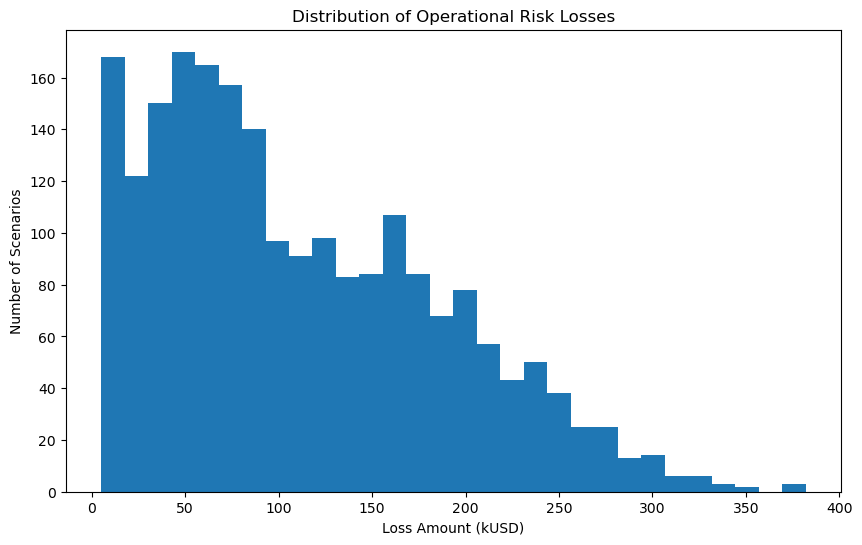

In [20]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Loss_Amount_(kUSD)"],
    bins=30
)

plt.title("Distribution of Operational Risk Losses")
plt.xlabel("Loss Amount (kUSD)")
plt.ylabel("Number of Scenarios")

plt.show()

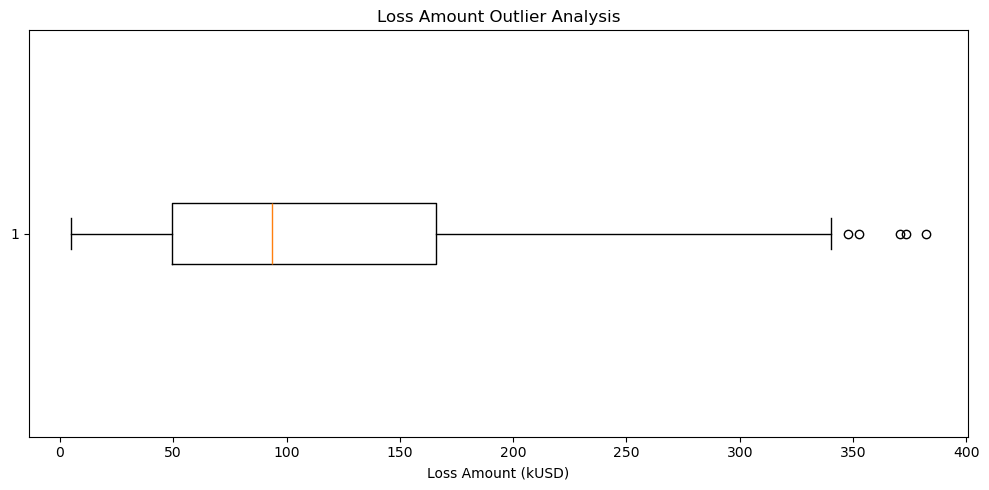

In [21]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    df["Loss_Amount_(kUSD)"].dropna(),
    vert=False
)

plt.title("Loss Amount Outlier Analysis")
plt.xlabel("Loss Amount (kUSD)")

plt.tight_layout()
plt.show()

In [24]:
event_analysis = (
    df.groupby("Event_Type")
      .agg(
          Scenario_Count=("Scenario_ID", "count"),
          Total_Loss_kUSD=("Loss_Amount_(kUSD)", "sum"),
          Average_Loss_kUSD=("Loss_Amount_(kUSD)", "mean"),
          Average_Severity=("Severity_(Xi)", "mean"),
          Average_Frequency=("Frequency_(Nk)", "mean")
      )
      .sort_values(
          "Total_Loss_kUSD",
          ascending=False
      )
)
event_analysis.round(2)

,Scenario_Count,Total_Loss_kUSD,Average_Loss_kUSD,Average_Severity,Average_Frequency
Event_Type,,,,,
System Failure,497,53811.56,108.27,1.48,2.90
Data Breach,494,52632.86,106.54,1.44,3.12
Tech Failure,454,47561.68,104.76,1.42,3.03
Cyber-Fraud,450,44748.60,99.44,1.47,2.91
Phishing,252,40789.80,161.86,1.90,2.97


In [25]:
process_analysis = (
    df.groupby("Process_Area")
      .agg(
          Scenario_Count=("Scenario_ID", "count"),
          Total_Loss_kUSD=("Loss_Amount_(kUSD)", "sum"),
          Average_Loss_kUSD=("Loss_Amount_(kUSD)", "mean"),
          Average_Severity=("Severity_(Xi)", "mean"),
          Average_Frequency=("Frequency_(Nk)", "mean")
      )
      .sort_values(
          "Total_Loss_kUSD",
          ascending=False
      )
)
process_analysis.round(2)

,Scenario_Count,Total_Loss_kUSD,Average_Loss_kUSD,Average_Severity,Average_Frequency
Process_Area,,,,,
Retail Banking,507,53743.59,106.00,1.46,3.05
ATM Network,478,52011.41,108.81,1.43,2.97
E-Banking,474,51838.15,109.36,1.51,3.03
Payments,465,48341.26,103.96,1.43,2.89
Online Services,223,33610.09,150.72,1.91,3.00


In [26]:
event_analysis["Loss_Contribution_%"] = (
    event_analysis["Total_Loss_kUSD"]
    / df["Loss_Amount_(kUSD)"].sum()
    * 100
)

event_analysis[
    [
        "Total_Loss_kUSD",
        "Loss_Contribution_%"
      ]].round(2)


,Total_Loss_kUSD,Loss_Contribution_%
Event_Type,,
System Failure,53811.56,22.46
Data Breach,52632.86,21.97
Tech Failure,47561.68,19.86
Cyber-Fraud,44748.60,18.68
Phishing,40789.80,17.03


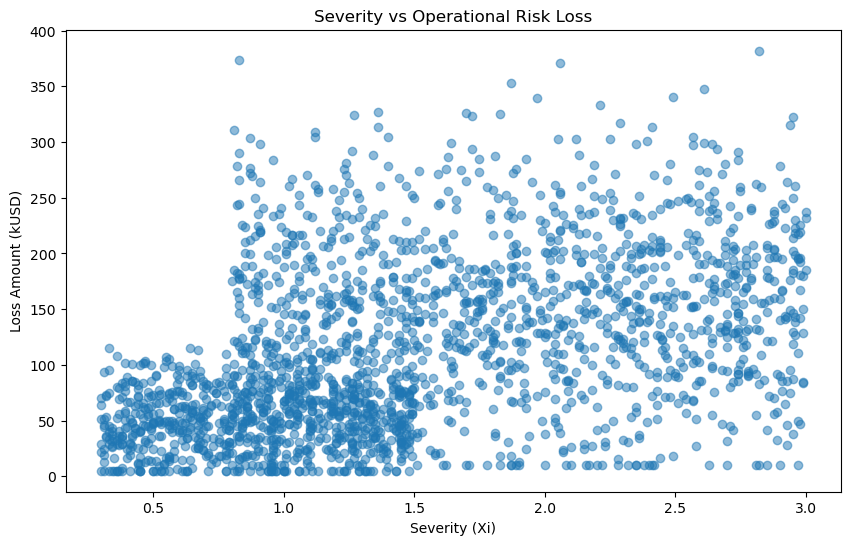

In [27]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Severity_(Xi)"],
    df["Loss_Amount_(kUSD)"],
    alpha=0.5
)

plt.title("Severity vs Operational Risk Loss")
plt.xlabel("Severity (Xi)")
plt.ylabel("Loss Amount (kUSD)")

plt.show()

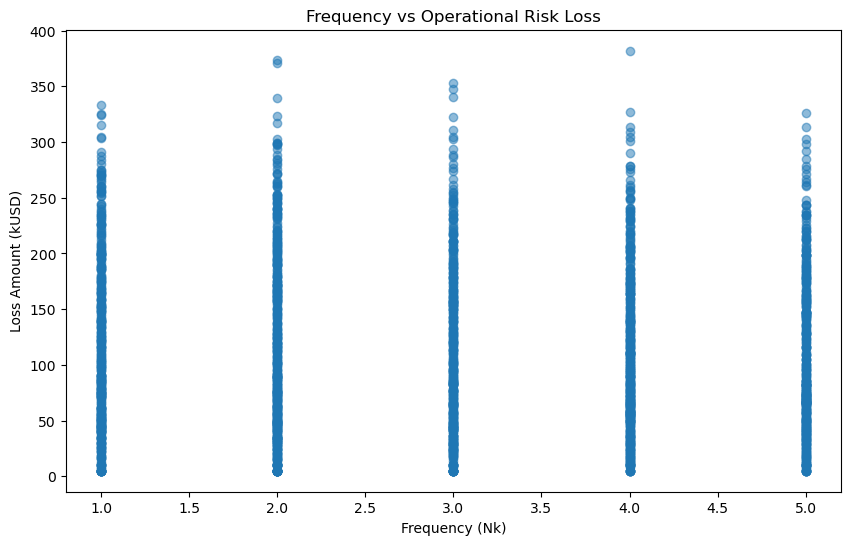

In [28]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Frequency_(Nk)"],
    df["Loss_Amount_(kUSD)"],
    alpha=0.5
)

plt.title("Frequency vs Operational Risk Loss")
plt.xlabel("Frequency (Nk)")
plt.ylabel("Loss Amount (kUSD)")

plt.show()

In [29]:
correlation_columns = [
    "Loss_Amount_(kUSD)",
    "Frequency_(Nk)",
    "Severity_(Xi)",
    "OpVar_(%)",
    "ML",
    "GDP_(%)",
    "VIX"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix.round(2)

,Loss_Amount_(kUSD),Frequency_(Nk),Severity_(Xi),OpVar_(%),ML,GDP_(%),VIX
Loss_Amount_(kUSD),1.00,-0.06,0.45,0.49,0.44,-0.03,0.23
Frequency_(Nk),-0.06,1.00,-0.02,-0.02,-0.01,0.02,-0.02
Severity_(Xi),0.45,-0.02,1.00,0.53,0.47,-0.04,0.23
OpVar_(%),0.49,-0.02,0.53,1.00,0.90,0.00,0.28
ML,0.44,-0.01,0.47,0.90,1.00,0.01,0.26
GDP_(%),-0.03,0.02,-0.04,0.00,0.01,1.00,-0.01
VIX,0.23,-0.02,0.23,0.28,0.26,-0.01,1.00


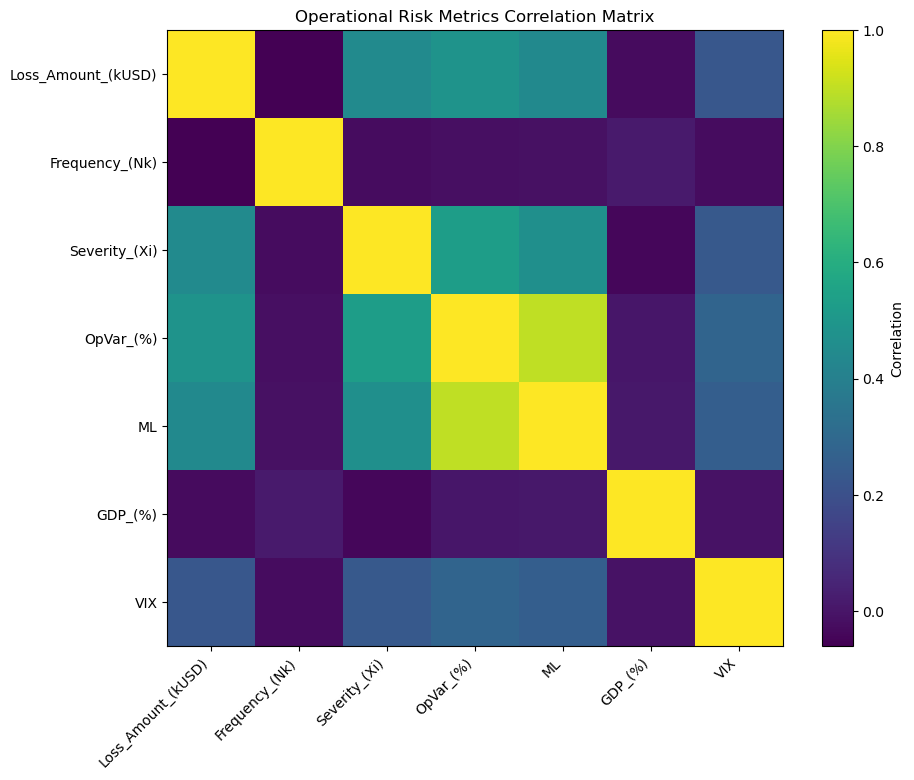

In [30]:
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix)
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)
plt.colorbar(label="Correlation")
plt.title("Operational Risk Metrics Correlation Matrix")

plt.show()

In [39]:
actual_date_df = df.copy()

# Convert "Null" text values to actual NaN
actual_date_df["Event_date"] = actual_date_df["Event_date"].replace(
    ["Null", "null", "NULL", ""],
    np.nan
)

# Convert Event_date to datetime
actual_date_df["Event_date"] = pd.to_datetime(
    actual_date_df["Event_date"],
    format="%d-%m-%Y",
    errors="coerce"
)

# Keep only records with valid actual dates
actual_date_df = actual_date_df[
    actual_date_df["Event_date"].notna()
].copy()

len(actual_date_df)
"Minimum Date:", actual_date_df["Event_date"].min()
"Maximum Date:", actual_date_df["Event_date"].max()

actual_date_df["Event_date"].dtype
actual_date_df[
        ["Scenario_ID", "Scenario_Type", "Event_date", "Event_Type"]
    ].head()

,Scenario_ID,Scenario_Type,Event_date,Event_Type
3,OLE-0760,OLE,2023-11-18,Cyber-Fraud
5,OLE-0110,OLE,2022-12-14,Tech Failure
7,OLE-0260,OLE,2023-05-25,Cyber-Fraud
9,OLE-0480,OLE,2022-08-23,Tech Failure
11,OLE-0837,OLE,2022-07-08,Cyber-Fraud


In [40]:
monthly_analysis = (
    actual_date_df
    .set_index("Event_date")
    .resample("ME")
    .agg(
        Scenario_Count=("Scenario_ID", "count"),
        Total_Loss_kUSD=("Loss_Amount_(kUSD)", "sum"),
        Average_Loss_kUSD=("Loss_Amount_(kUSD)", "mean")
    )
)

monthly_analysis.round(2)

,Scenario_Count,Total_Loss_kUSD,Average_Loss_kUSD
Event_date,,,
2022-01-31,31,1458.15,47.04
2022-02-28,29,1423.34,49.08
2022-03-31,46,2429.16,52.81
2022-04-30,42,2015.86,48.00
2022-05-31,34,1897.47,55.81
2022-06-30,37,2202.49,59.53
2022-07-31,28,1382.50,49.38
2022-08-31,22,1113.63,50.62
2022-09-30,45,2005.43,44.57


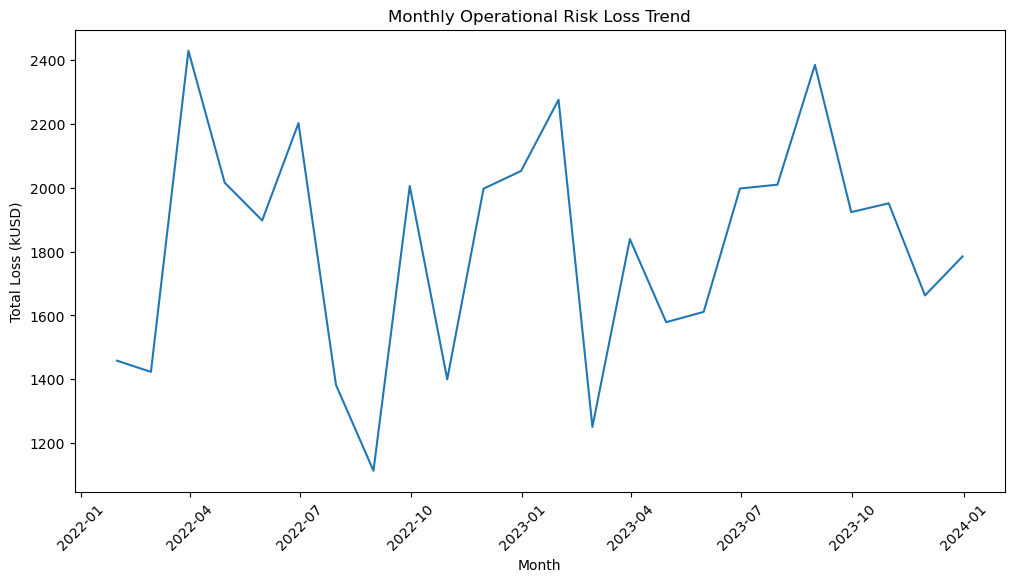

In [41]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_analysis.index,
    monthly_analysis["Total_Loss_kUSD"]
)

plt.title("Monthly Operational Risk Loss Trend")
plt.xlabel("Month")
plt.ylabel("Total Loss (kUSD)")

plt.xticks(rotation=45)
plt.show()

In [42]:
scenario_analysis = (
    df.groupby("Scenario_Type")
      .agg(
          Scenario_Count=("Scenario_ID", "count"),
          Total_Loss_kUSD=("Loss_Amount_(kUSD)", "sum"),
          Average_Loss_kUSD=("Loss_Amount_(kUSD)", "mean"),
          Average_Severity=("Severity_(Xi)", "mean"),
          Average_Frequency=("Frequency_(Nk)", "mean")
      )
      .sort_values(
          "Total_Loss_kUSD",
          ascending=False
      )
)

scenario_analysis.round(2)

,Scenario_Count,Total_Loss_kUSD,Average_Loss_kUSD,Average_Severity,Average_Frequency
Scenario_Type,,,,,
ALE,1289,195897.18,151.98,1.9,2.96
OLE,858,43647.32,50.87,0.9,3.03


In [44]:
def assign_risk_band(row):

    if (
        row["Severity_(Xi)"] >= 2.5
        and row["Loss_Amount_(kUSD)"] >= 250
    ):
        return "High Risk"

    elif (
        row["Severity_(Xi)"] >= 1.5
        or row["Loss_Amount_(kUSD)"] >= 150
    ):
        return "Medium Risk"

    else:
        return "Lower Risk"


df["Analytical_Risk_Band"] = df.apply(
    assign_risk_band,
    axis=1
)

In [45]:
risk_band_analysis = (
    df.groupby("Analytical_Risk_Band")
      .agg(
          Scenario_Count=("Scenario_ID", "count"),
          Total_Loss_kUSD=("Loss_Amount_(kUSD)", "sum"),
          Average_Loss_kUSD=("Loss_Amount_(kUSD)", "mean")
      )
      .sort_values(
          "Total_Loss_kUSD",
          ascending=False
      )
)

risk_band_analysis.round(2)

,Scenario_Count,Total_Loss_kUSD,Average_Loss_kUSD
Analytical_Risk_Band,,,
Medium Risk,1078,171044.76,158.67
Lower Risk,1043,61103.69,58.58
High Risk,26,7396.05,284.46


In [46]:
with pd.ExcelWriter(
    "Operational_Risk_Python_Analysis.xlsx",
    engine="openpyxl"
) as writer:
    event_analysis.round(2).to_excel(
        writer,
        sheet_name="Event_Analysis"
    )
    process_analysis.round(2).to_excel(
        writer,
        sheet_name="Process_Analysis"
    )
    scenario_analysis.round(2).to_excel(
        writer,
        sheet_name="ALE_vs_OLE"
    )
    risk_band_analysis.round(2).to_excel(
        writer,
        sheet_name="Risk_Bands"
    )
    monthly_analysis.round(2).to_excel(
        writer,
        sheet_name="Monthly_Analysis"
    )
    correlation_matrix.round(2).to_excel(
        writer,
        sheet_name="Correlation"
    )
print(
    "\nPython analysis exported successfully."
)


Python analysis exported successfully.
